# Compare saved detector runs
Change `RUNS`, `SELECTION_MODE`, and `POLICY` in the next cell. For real comparisons, point each alias at a different run's `threshold_comparison` directory. Summary sections load exported scores; the final example-inspection section replays saved checkpoints on current validation data at their exported operating points. It does not retrain, resweep thresholds, or retune a model.

Selections and scores below come from the same validation recordings (`tuned_validation`), so these are descriptive comparisons, not independent test-set estimates. The loader rejects incompatible data, preprocessing, threshold grids, matching rules, or selection constraints.

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'

RUNS = {
    'Baseline': 'testing_checkpoints/baseline_no_changes/threshold_comparison',
    '(labels delayed 5 frames)': 'testing_checkpoints/baseline_delay_5/threshold_comparison',
    '(labels delayed 8 frames)': 'testing_checkpoints/baseline_delay_8/threshold_comparison',
    '(labels delayed 8 frames, patience 15)': 'testing_checkpoints/baseline_delay_8_patience_15/threshold_comparison',
}
SELECTION_MODE = 'max_f1'
POLICY = 'lookahead_12f'
assert len(RUNS) >= 2, 'Provide at least two uniquely named runs.'

def read_export(directory, name):
    path = directory / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(f'{path}: rerun the export cell in baseline_evaluation.ipynb')
    return pd.read_csv(path)

sources, selections, summaries, type_tables, file_tables = [], [], [], [], []
for label, folder in RUNS.items():
    directory = ROOT / folder
    selected = read_export(directory, 'selected_thresholds')
    chosen = selected[(selected.selection_mode == SELECTION_MODE) & (selected.policy == POLICY)]
    if len(chosen) != 1:
        raise ValueError(f'{label}: expected exactly one selection for {SELECTION_MODE}/{POLICY}')
    choice = chosen.iloc[0]
    if not bool(choice.feasible):
        raise ValueError(f'{label}: requested selection is infeasible: {choice.infeasible_reason}')
    tables = [read_export(directory, name) for name in
              ('comparison_summary', 'type_metrics_all_modes', 'recording_metrics_all_modes')]
    matching = [table[(table.selection_mode == SELECTION_MODE) & (table.policy == POLICY)].copy()
                for table in tables]
    for table in matching:
        assert len(table), f'{label}: selected mode/policy missing in an exported table'
        assert np.allclose(table.left_threshold, choice.left_threshold)
        assert np.allclose(table.right_threshold, choice.right_threshold)
        assert table.checkpoint_sha256.nunique() == 1
        assert table.checkpoint_sha256.iloc[0] == choice.checkpoint_sha256
        table['model'] = label
    summary, by_type, by_file = matching
    assert set(summary.level) == {'window', 'frame', 'event'}
    assert set(summary.side) == {'all', 'left', 'right'}
    assert len(summary) == 9
    for kind in ('window', 'event'):
        overall = summary[(summary.level == kind) & (summary.side == 'all')].iloc[0]
        for count in ('tp', 'fp', 'fn'):
            assert by_file[f'{kind}_{count}'].sum() == by_type[f'{kind}_{count}'].sum() == overall[count]
    sources.append(dict(model=label, folder=str(directory), model_id=choice.model_id,
                        checkpoint_sha256=choice.checkpoint_sha256,
                        validation_sha256=choice.validation_sha256,
                        preprocessing_sha256=choice.preprocessing_sha256,
                        evaluation_design=choice.evaluation_design))
    selections.append(choice.to_dict() | {'model': label})
    summaries.append(summary)
    type_tables.append(by_type)
    file_tables.append(by_file)
comparison_sources = pd.DataFrame(sources)
operating_points = pd.DataFrame(selections)
scores = pd.concat(summaries, ignore_index=True)
type_scores = pd.concat(type_tables, ignore_index=True)
file_scores = pd.concat(file_tables, ignore_index=True)
must_agree = ['validation_sha256', 'preprocessing_sha256', 'selection_split',
              'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
              'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
              'max_late_frames', 'refractory_sec', 'frame_label_half_width']
for field in must_agree:
    assert scores[field].nunique(dropna=False) == 1, f'Runs differ in {field}; comparison is not like-for-like'
first_label = next(iter(RUNS))
expected_files = set(file_scores[file_scores.model == first_label].file)
expected_types = set(type_scores[type_scores.model == first_label].recording_type)
for label in RUNS:
    assert set(file_scores[file_scores.model == label].file) == expected_files, 'Recordings differ'
    assert set(type_scores[type_scores.model == label].recording_type) == expected_types, 'Types differ'
if comparison_sources.checkpoint_sha256.nunique() < len(RUNS):
    print('Demo: some aliases use identical weights. Replace RUNS paths to compare different models.')
comparison_sources

,model,folder,model_id,checkpoint_sha256,validation_sha256,preprocessing_sha256,evaluation_design
0,Baseline,/home/aprohack/desktop/work/tap-project/projec...,20260929_170446,49f96114aef2d92764780cd0d0024ebe7db6aade778445...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
1,(labels delayed 5 frames),/home/aprohack/desktop/work/tap-project/projec...,20260929_173706,dc7b4be3469c0c7aa580d561a7b3bf284bccc72a33f40e...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
2,(labels delayed 8 frames),/home/aprohack/desktop/work/tap-project/projec...,baseline_delay_8,e1dc5ca05772b3734c2ccaff82b6fa7e3f19aa49d86bb7...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation
3,"(labels delayed 8 frames, patience 15)",/home/aprohack/desktop/work/tap-project/projec...,baseline_delay_8_patience_15,2adf4f61929be8ca4b2b5dc2501992e4e68e5daa57be23...,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,3a9e3e30519e8842db73efa2fd88f7409925871ac406de...,tuned_validation


In [24]:
operating_points[['model', 'selection_mode', 'policy', 'left_threshold', 'right_threshold',
                  'macro_f1', 'left_recall', 'right_recall', 'fp_per_min']]

,model,selection_mode,policy,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min
0,Baseline,max_f1,lookahead_12f,0.65,0.80,0.923774,0.917197,0.894737,0.604280
1,(labels delayed 5 frames),max_f1,lookahead_12f,0.60,0.70,0.940237,0.949045,0.953216,0.805707
2,(labels delayed 8 frames),max_f1,lookahead_12f,0.70,0.65,0.950594,0.968153,0.953216,0.671423
3,"(labels delayed 8 frames, patience 15)",max_f1,lookahead_12f,0.75,0.70,0.926175,0.942675,0.935673,0.973563


## Window classification
All models use their **selected** left/right thresholds. Bar heights are per-window metrics, not event alarm quality. `class_accuracy` requires the correct side; binary accuracy treats either side as a detected event. PR-AUC is threshold-independent.

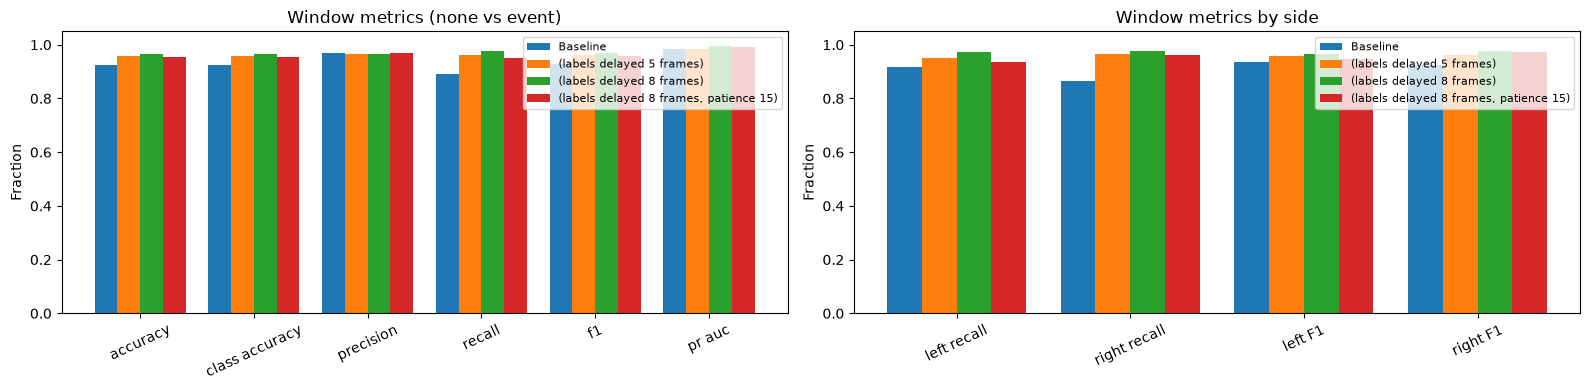

In [25]:
def grouped_bars(ax, table, columns, title, *, scale=1, ylabel='Score'):
    x = np.arange(len(columns))
    width = .8 / len(table)
    for i, (_, row) in enumerate(table.iterrows()):
        values = [row[column] * scale for column in columns]
        ax.bar(x - .4 + width*(i+.5), values, width, label=row['model'])
    ax.set(xticks=x, xticklabels=[name.replace('_', ' ') for name in columns],
           title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

window_metrics = scores[scores.level == 'window'].copy()
overall = window_metrics[window_metrics.side == 'all']
by_side = window_metrics[window_metrics.side != 'all'].copy()
by_side['side_recall'] = by_side.side + ' recall'
by_side['side_f1'] = by_side.side + ' F1'
per_side = pd.concat([
    by_side.pivot(index='model', columns='side_recall', values='recall'),
    by_side.pivot(index='model', columns='side_f1', values='f1')], axis=1).reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
grouped_bars(axes[0], overall, ['accuracy', 'class_accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
             'Window metrics (none vs event)', ylabel='Fraction')
grouped_bars(axes[1], per_side, [c for c in per_side if c != 'model'],
             'Window metrics by side', ylabel='Fraction')
for ax in axes: ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [26]:
window_metrics[['model', 'side', 'left_threshold', 'right_threshold', 'n_samples',
                'tp', 'fp', 'fn', 'tn', 'accuracy', 'class_accuracy', 'precision',
                'recall', 'f1', 'pr_auc', 'roc_auc']]  # Full table: window_metrics.

,model,side,left_threshold,right_threshold,n_samples,tp,fp,fn,tn,accuracy,class_accuracy,precision,recall,f1,pr_auc,roc_auc
0,Baseline,all,0.65,0.80,598.0,301.0,9.0,37.0,251.0,0.923077,0.923077,0.970968,0.890533,0.929012,0.983860,0.979529
1,Baseline,left,0.65,0.80,598.0,145.0,7.0,13.0,433.0,0.966555,NaN,0.953947,0.917722,0.935484,0.980236,0.992966
2,Baseline,right,0.65,0.80,598.0,156.0,2.0,24.0,416.0,0.956522,NaN,0.987342,0.866667,0.923077,0.984791,0.992703
9,(labels delayed 5 frames),all,0.60,0.70,598.0,325.0,12.0,13.0,248.0,0.958194,0.956522,0.964392,0.961538,0.962963,0.984703,0.984092
10,(labels delayed 5 frames),left,0.60,0.70,598.0,150.0,5.0,8.0,435.0,0.978261,NaN,0.967742,0.949367,0.958466,0.987748,0.993628
11,(labels delayed 5 frames),right,0.60,0.70,598.0,174.0,8.0,6.0,410.0,0.976589,NaN,0.956044,0.966667,0.961326,0.980004,0.991746
18,(labels delayed 8 frames),all,0.70,0.65,598.0,330.0,12.0,8.0,248.0,0.966555,0.966555,0.964912,0.976331,0.970588,0.994156,0.992945
19,(labels delayed 8 frames),left,0.70,0.65,598.0,154.0,7.0,4.0,433.0,0.981605,NaN,0.956522,0.974684,0.965517,0.990250,0.997224
20,(labels delayed 8 frames),right,0.70,0.65,598.0,176.0,5.0,4.0,413.0,0.984950,NaN,0.972376,0.977778,0.975069,0.994832,0.997554
27,"(labels delayed 8 frames, patience 15)",all,0.75,0.70,598.0,321.0,10.0,17.0,250.0,0.954849,0.954849,0.969789,0.949704,0.959641,0.991350,0.990350


## Frame diagnostics
These per-frame values depend on the selected thresholds, except PR-AUC/ROC-AUC. Frames near the same physical event are correlated; streaming event results below are the primary product metrics.

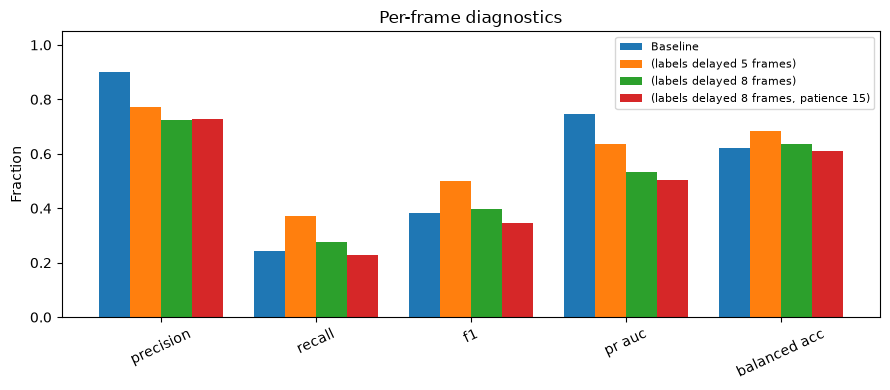

In [27]:
frame_metrics = scores[scores.level == 'frame'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
grouped_bars(ax, frame_metrics[frame_metrics.side == 'all'],
             ['precision', 'recall', 'f1', 'pr_auc', 'balanced_acc'],
             'Per-frame diagnostics', ylabel='Fraction')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [28]:
frame_metrics[['model', 'side', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
               'n_samples', 'tp', 'fp', 'fn']]  # Full table: frame_metrics.

,model,side,precision,recall,f1,pr_auc,roc_auc,n_samples,tp,fp,fn
3,Baseline,all,0.902361,0.244193,0.384369,0.745056,0.980476,178725.0,1682.0,182.0,5206.0
4,Baseline,left,0.891785,0.342433,0.494850,0.744099,0.987155,178725.0,1129.0,137.0,2168.0
5,Baseline,right,0.924749,0.153996,0.264025,0.740296,0.988806,178725.0,553.0,45.0,3038.0
12,(labels delayed 5 frames),all,0.772837,0.370935,0.501275,0.635325,0.962498,178725.0,2555.0,751.0,4333.0
13,(labels delayed 5 frames),left,0.736527,0.410373,0.527074,0.604257,0.974620,178725.0,1353.0,484.0,1944.0
14,(labels delayed 5 frames),right,0.818244,0.334726,0.475099,0.654229,0.976523,178725.0,1202.0,267.0,2389.0
21,(labels delayed 8 frames),all,0.723201,0.274245,0.397684,0.534291,0.950161,178725.0,1889.0,723.0,4999.0
22,(labels delayed 8 frames),left,0.734928,0.232939,0.353754,0.472179,0.963760,178725.0,768.0,277.0,2529.0
23,(labels delayed 8 frames),right,0.715380,0.312169,0.434665,0.584119,0.976246,178725.0,1121.0,446.0,2470.0
30,"(labels delayed 8 frames, patience 15)",all,0.728078,0.226626,0.345660,0.502880,0.945972,178725.0,1561.0,583.0,5327.0


## Streaming event detection
Event matching is class-aware, one-to-one, and uses the **actual alarm-emission frame**. FP/min counts unmatched alarms over all validation minutes, including early and wrong-side alarms. The selected operating point can differ per model even though its selection mode is the same.

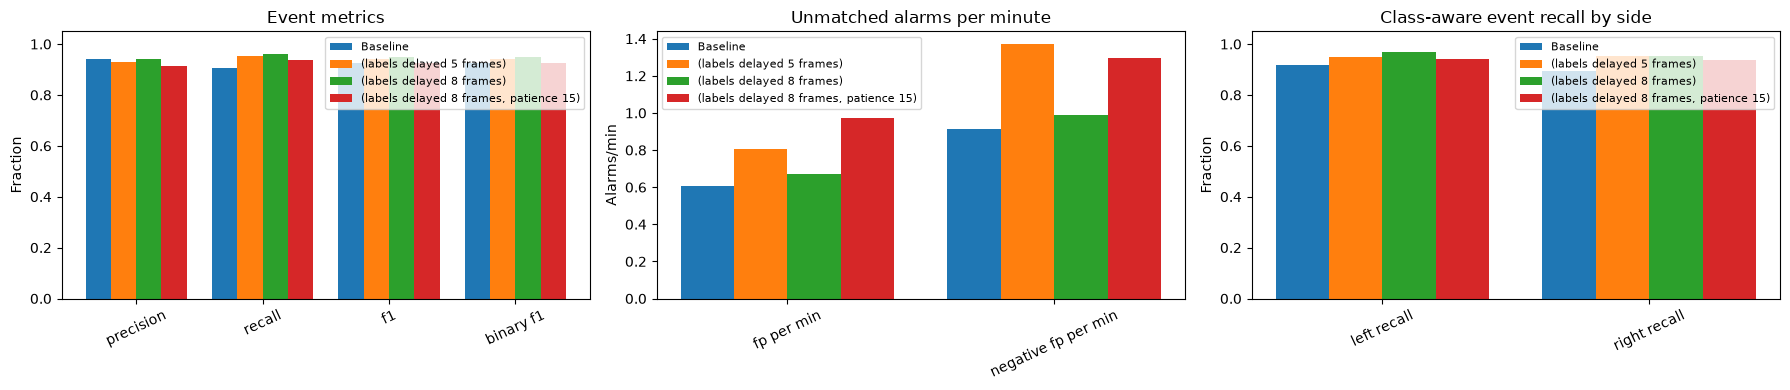

In [29]:
event_metrics = scores[scores.level == 'event'].copy()
event_overall = event_metrics[event_metrics.side == 'all']
event_side = event_metrics[event_metrics.side != 'all'].copy()
event_side['side_recall'] = event_side.side + ' recall'
side_recall = event_side.pivot(index='model', columns='side_recall', values='recall').reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
grouped_bars(axes[0], event_overall, ['precision', 'recall', 'f1', 'binary_f1'],
             'Event metrics', ylabel='Fraction')
grouped_bars(axes[1], event_overall, ['fp_per_min', 'negative_fp_per_min'],
             'Unmatched alarms per minute', ylabel='Alarms/min')
grouped_bars(axes[2], side_recall, [c for c in side_recall if c != 'model'],
             'Class-aware event recall by side', ylabel='Fraction')
axes[0].set_ylim(0, 1.05)
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [30]:
event_metrics[['model', 'side', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'binary_f1', 'fp_per_min', 'negative_fp_per_min',
               'left_threshold', 'right_threshold']]  # Full table: event_metrics.

,model,side,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min,left_threshold,right_threshold
6,Baseline,all,297.0,18.0,31.0,0.942857,0.905488,0.923795,0.923795,0.604280,0.914123,0.65,0.80
7,Baseline,left,144.0,11.0,13.0,0.929032,0.917197,0.923077,NaN,0.369282,0.685592,0.65,0.80
8,Baseline,right,153.0,7.0,18.0,0.956250,0.894737,0.924471,NaN,0.234998,0.228531,0.65,0.80
15,(labels delayed 5 frames),all,312.0,24.0,16.0,0.928571,0.951220,0.939759,0.939759,0.805707,1.371185,0.60,0.70
16,(labels delayed 5 frames),left,149.0,8.0,8.0,0.949045,0.949045,0.949045,NaN,0.268569,0.533239,0.60,0.70
17,(labels delayed 5 frames),right,163.0,16.0,8.0,0.910615,0.953216,0.931429,NaN,0.537138,0.837946,0.60,0.70
24,(labels delayed 8 frames),all,315.0,20.0,13.0,0.940299,0.960366,0.950226,0.950226,0.671423,0.990300,0.70,0.65
25,(labels delayed 8 frames),left,152.0,8.0,5.0,0.950000,0.968153,0.958991,NaN,0.268569,0.533239,0.70,0.65
26,(labels delayed 8 frames),right,163.0,12.0,8.0,0.931429,0.953216,0.942197,NaN,0.402854,0.457062,0.70,0.65
33,"(labels delayed 8 frames, patience 15)",all,308.0,29.0,20.0,0.913947,0.939024,0.926316,0.926316,0.973563,1.295008,0.75,0.70


## Alarm latency
Deadline recall is the fraction of **all annotated events** detected before X frames (misses remain in the denominator). Mean/median/p90 latency includes matched events only and can be misleading if recall is low.

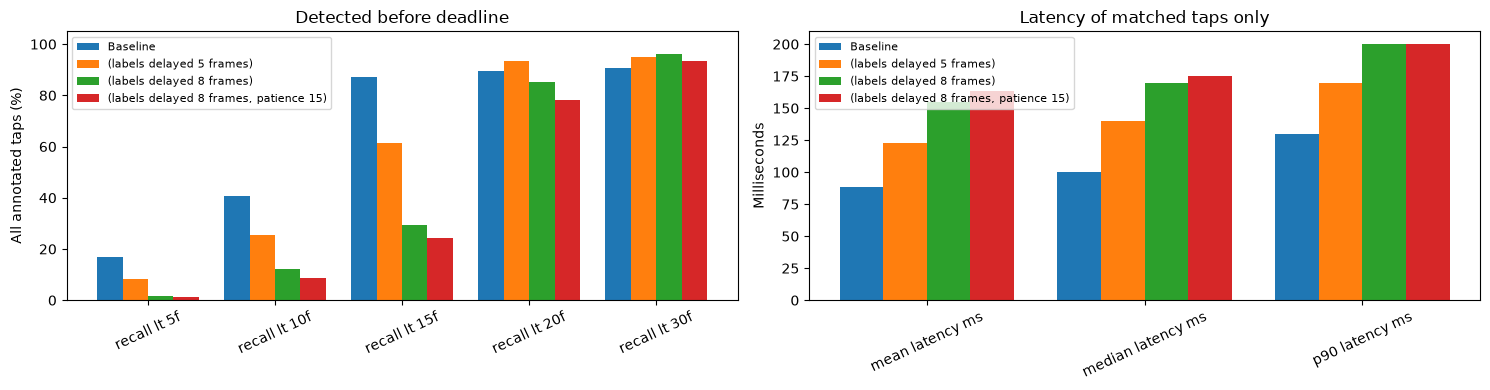

In [31]:
latency_metrics = event_overall[['model', 'left_threshold', 'right_threshold',
                                 'recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f',
                                 'recall_lt_20f', 'recall_lt_30f', 'mean_latency_ms',
                                 'median_latency_ms', 'p90_latency_ms', 'tp', 'fn']].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
grouped_bars(axes[0], latency_metrics,
             ['recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f', 'recall_lt_20f', 'recall_lt_30f'],
             'Detected before deadline', scale=100, ylabel='All annotated taps (%)')
grouped_bars(axes[1], latency_metrics,
             ['mean_latency_ms', 'median_latency_ms', 'p90_latency_ms'],
             'Latency of matched taps only', ylabel='Milliseconds')
axes[0].set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [32]:
latency_metrics  # Filter model and compare recall/latency at the same deadline.

,model,left_threshold,right_threshold,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,mean_latency_ms,median_latency_ms,p90_latency_ms,tp,fn
6,Baseline,0.65,0.80,0.170732,0.405488,0.871951,0.896341,0.905488,88.215488,100.0,130.0,297.0,31.0
15,(labels delayed 5 frames),0.60,0.70,0.082317,0.253049,0.615854,0.935976,0.951220,122.852564,140.0,170.0,312.0,16.0
24,(labels delayed 8 frames),0.70,0.65,0.015244,0.121951,0.292683,0.853659,0.960366,154.984127,170.0,200.0,315.0,13.0
33,"(labels delayed 8 frames, patience 15)",0.75,0.70,0.012195,0.085366,0.243902,0.783537,0.935976,163.571429,175.0,200.0,308.0,20.0


## Recording types and individual files
Rows use the same selected policy and left/right thresholds as the event and window plots. Negative-only types have undefined event recall; their FP/min and false-positive window rates are the useful metrics. Grouped by type, every value is pooled over its files (not an average of file percentages). Some types contain only one file.

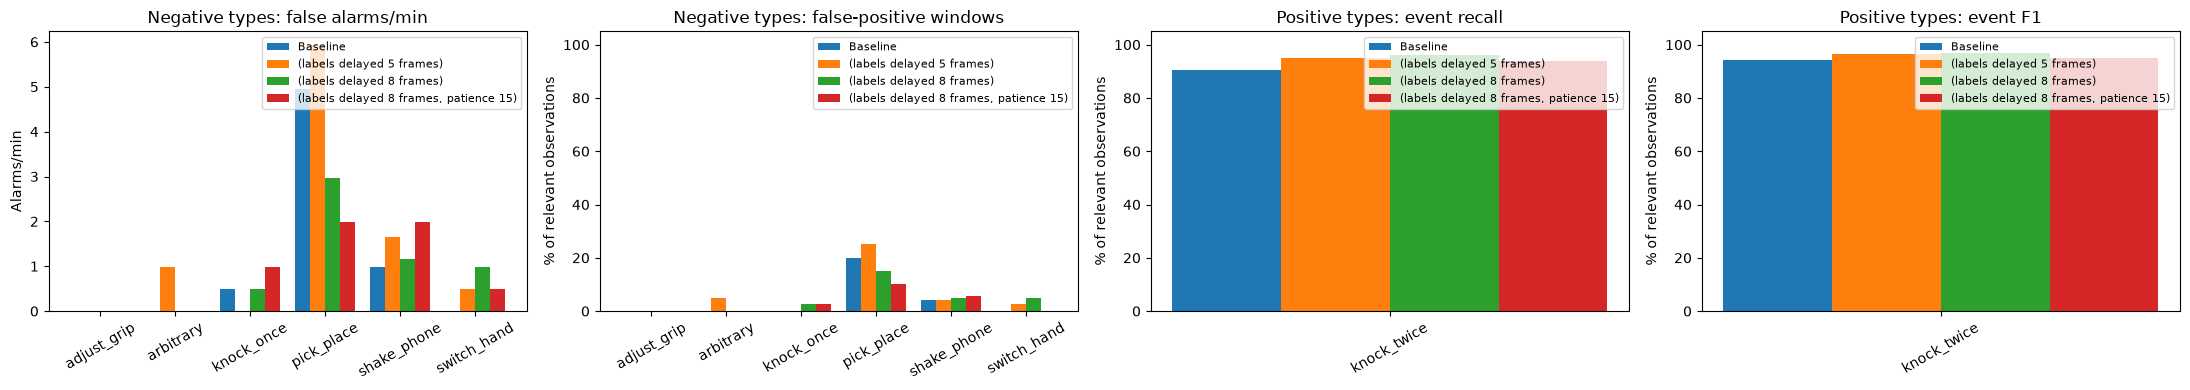

In [33]:
type_comparison = type_scores.copy()
negative = type_comparison[type_comparison.n_true_events == 0]
positive = type_comparison[type_comparison.n_true_events > 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, subset, metric, title, scale in [
        (axes[0], negative, 'event_fp_per_min', 'Negative types: false alarms/min', 1),
        (axes[1], negative, 'window_false_positive_rate', 'Negative types: false-positive windows', 100),
        (axes[2], positive, 'event_recall', 'Positive types: event recall', 100),
        (axes[3], positive, 'event_f1', 'Positive types: event F1', 100)]:
    x = sorted(subset.recording_type.unique())
    width = .8 / len(RUNS)
    for i, label in enumerate(RUNS):
        rows = subset[subset.model == label].set_index('recording_type').reindex(x)
        ax.bar(np.arange(len(x)) - .4 + width*(i+.5), rows[metric] * scale, width, label=label)
    ax.set(xticks=np.arange(len(x)), xticklabels=x, title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Alarms/min')
for ax in axes[1:]: ax.set(ylabel='% of relevant observations', ylim=(0, 105))
plt.tight_layout()
plt.show()

In [34]:
type_comparison[['model', 'recording_type', 'recordings', 'n_windows', 'n_true_events',
                 'event_tp', 'event_fp', 'event_fn', 'event_f1', 'event_fp_per_min',
                 'event_left_recall', 'event_right_recall', 'window_accuracy',
                 'window_false_positive_rate']]  # Full table: type_comparison.

,model,recording_type,recordings,n_windows,n_true_events,event_tp,event_fp,event_fn,event_f1,event_fp_per_min,event_left_recall,event_right_recall,window_accuracy,window_false_positive_rate
0,Baseline,adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
1,Baseline,arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
2,Baseline,knock_once,2,40,0,0,1,0,0.000000,0.495540,NaN,NaN,1.000000,0.000000
3,Baseline,knock_twice,17,338,328,297,6,31,0.941363,0.360140,0.917197,0.894737,0.890533,NaN
4,Baseline,pick_place,1,20,0,0,5,0,0.000000,4.948862,NaN,NaN,0.800000,0.200000
5,Baseline,shake_phone,6,120,0,0,6,0,0.000000,0.990344,NaN,NaN,0.958333,0.041667
6,Baseline,switch_hand,2,40,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
7,(labels delayed 5 frames),adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
8,(labels delayed 5 frames),arbitrary,1,20,0,0,1,0,0.000000,0.989772,NaN,NaN,0.950000,0.050000
9,(labels delayed 5 frames),knock_once,2,40,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000


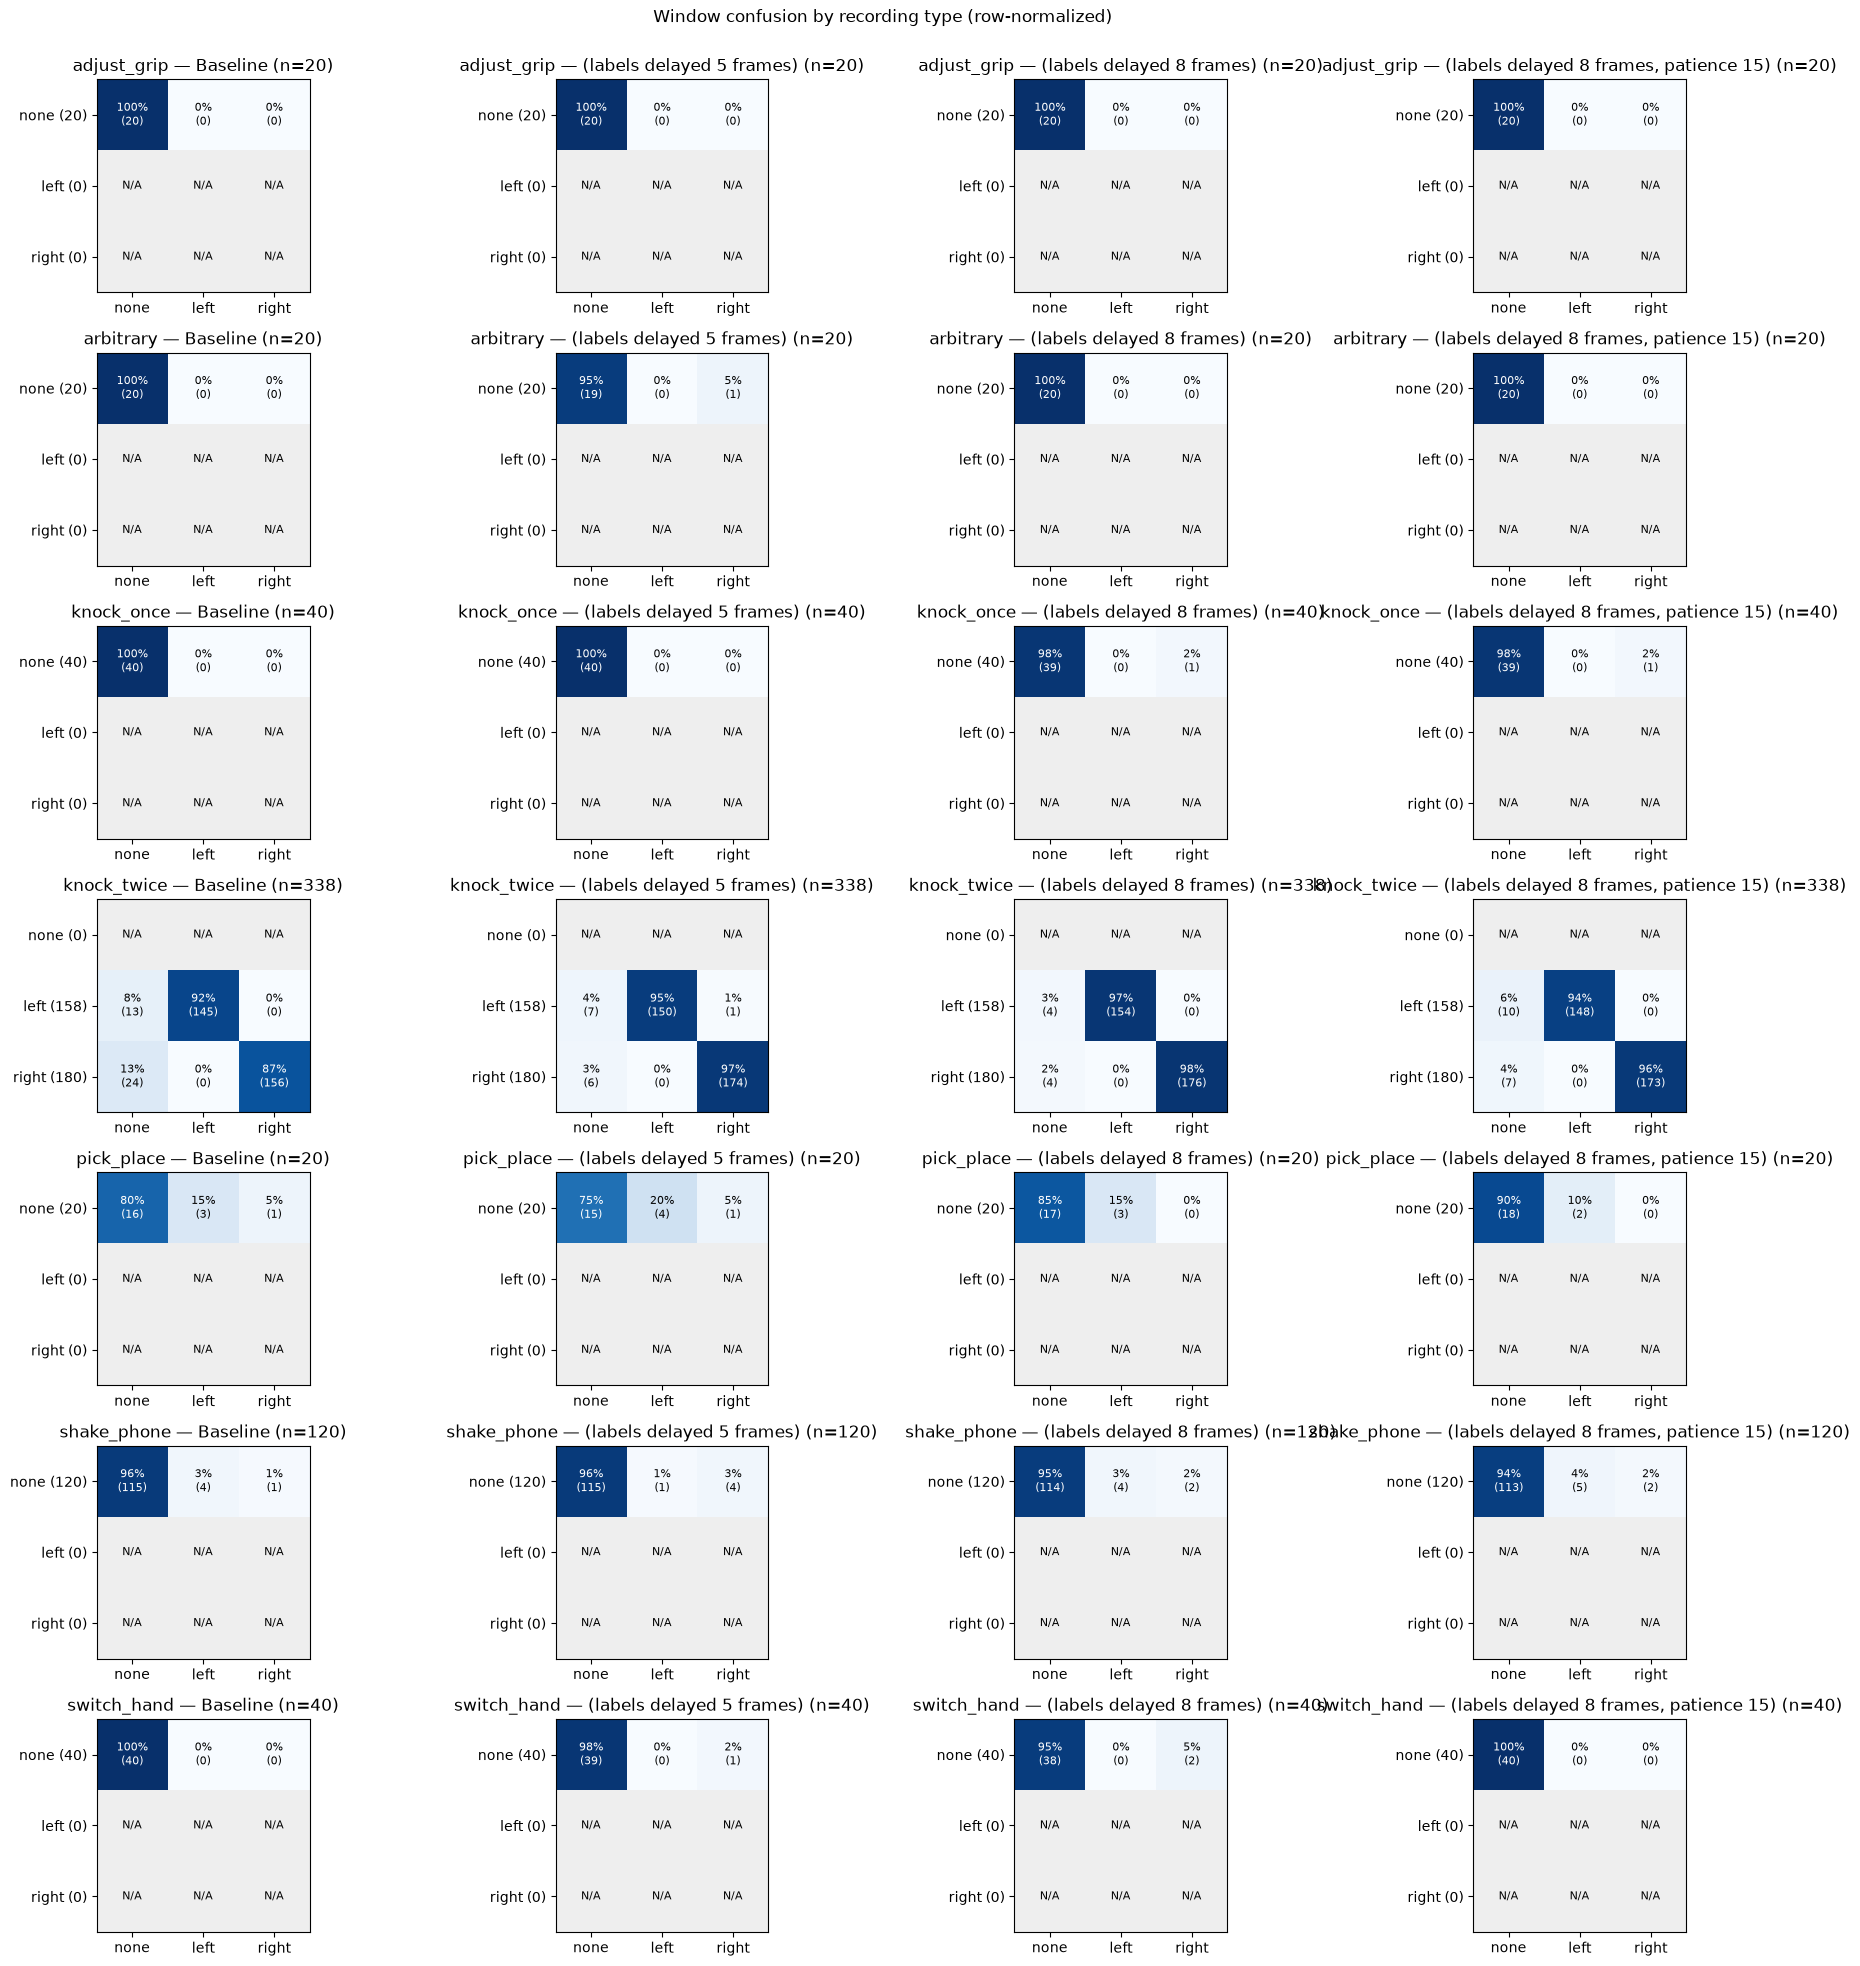

In [35]:
from matplotlib.colors import Normalize
confusion_rows = []
recording_types = sorted(expected_types)
fig, axes = plt.subplots(len(recording_types), len(RUNS),
                         figsize=(4.8*len(RUNS), 2.8*len(recording_types)), squeeze=False)
colors = plt.get_cmap('Blues').copy()
colors.set_bad('#eeeeee')
for i, recording_type in enumerate(recording_types):
    for j, model_name in enumerate(RUNS):
        row = type_comparison[(type_comparison.recording_type == recording_type) &
                              (type_comparison.model == model_name)].iloc[0]
        cm = np.array([[int(row[f'cm_{t}{p}']) for p in range(3)] for t in range(3)])
        totals = cm.sum(axis=1)
        fractions = np.divide(cm, totals[:, None], out=np.full((3, 3), np.nan),
                              where=totals[:, None] > 0)
        ax = axes[i, j]
        ax.imshow(np.ma.masked_invalid(fractions), cmap=colors, norm=Normalize(0, 1))
        ax.set(title=f'{recording_type} — {model_name} (n={cm.sum()})',
               xticks=range(3), xticklabels=('none', 'left', 'right'),
               yticks=range(3), yticklabels=[f'{name} ({n})' for name, n in
                                        zip(('none', 'left', 'right'), totals)])
        for t, true_class in enumerate(('none', 'left', 'right')):
            for p, predicted_class in enumerate(('none', 'left', 'right')):
                ax.text(p, t, f'{fractions[t, p]:.0%}\n({cm[t, p]})' if totals[t] else 'N/A',
                        ha='center', va='center', fontsize=8,
                        color='white' if totals[t] and fractions[t, p] > .55 else 'black')
                confusion_rows.append(dict(model=model_name, recording_type=recording_type,
                                           true_class=true_class, predicted_class=predicted_class,
                                           count=int(cm[t, p]), true_count=int(totals[t]),
                                           row_fraction=fractions[t, p]))
fig.suptitle('Window confusion by recording type (row-normalized)', y=1.001)
plt.tight_layout()
plt.show()
type_confusion_comparison = pd.DataFrame(confusion_rows)

In [36]:
type_confusion_comparison  # N/A rows have no observed examples of that true class.

,model,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,Baseline,adjust_grip,none,none,20,20,1.0
1,Baseline,adjust_grip,none,left,0,20,0.0
2,Baseline,adjust_grip,none,right,0,20,0.0
3,Baseline,adjust_grip,left,none,0,0,NaN
4,Baseline,adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...,...
247,"(labels delayed 8 frames, patience 15)",switch_hand,left,left,0,0,NaN
248,"(labels delayed 8 frames, patience 15)",switch_hand,left,right,0,0,NaN
249,"(labels delayed 8 frames, patience 15)",switch_hand,right,none,0,0,NaN
250,"(labels delayed 8 frames, patience 15)",switch_hand,right,left,0,0,NaN


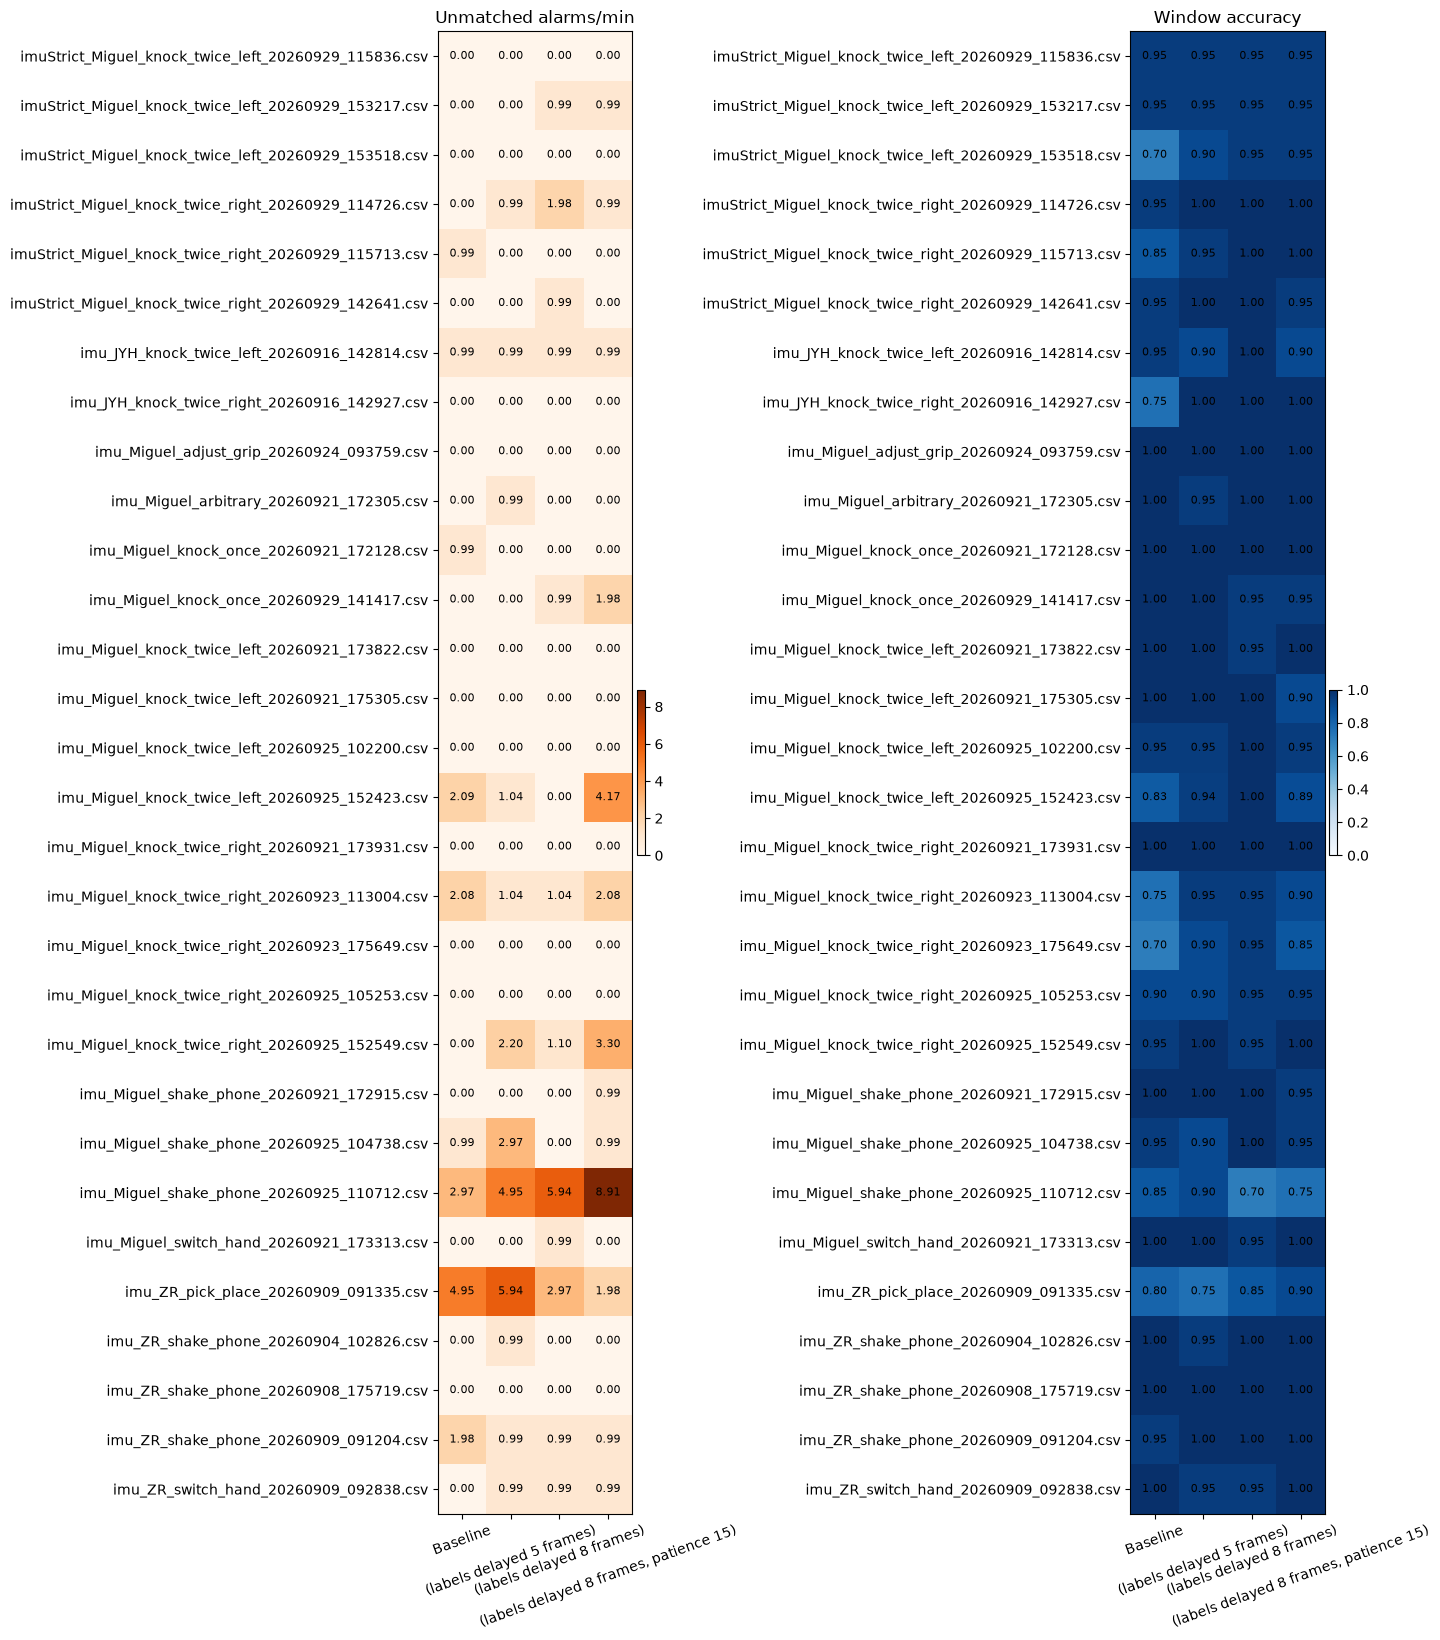

In [37]:
recording_comparison = file_scores.copy()
files = sorted(recording_comparison.file.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, .55*len(files))))
for ax, field, label, cmap in [
        (axes[0], 'event_fp_per_min', 'Unmatched alarms/min', 'Oranges'),
        (axes[1], 'window_accuracy', 'Window accuracy', 'Blues')]:
    table = recording_comparison.pivot(index='file', columns='model', values=field).reindex(
        index=files, columns=list(RUNS))
    data = table.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=1 if field == 'window_accuracy' else None)
    ax.set(yticks=np.arange(len(files)), yticklabels=files, xticks=np.arange(len(RUNS)),
           xticklabels=list(RUNS), title=label)
    ax.tick_params(axis='x', rotation=20)
    for i in range(len(files)):
        for j in range(len(RUNS)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
plt.tight_layout()
plt.show()

In [39]:
recording_comparison[['model', 'file', 'recording_type', 'n_windows',
                      'n_true_events', 'event_tp', 'event_fp', 'event_fn',
                      'window_fp', 'window_fn', 'event_fp_per_min', 'minutes']]  # Full table: recording_comparison.

,model,file,recording_type,n_windows,n_true_events,event_tp,event_fp,event_fn,window_fp,window_fn,event_fp_per_min,minutes
0,Baseline,imuStrict_Miguel_knock_twice_left_20260929_115...,knock_twice,20,20,19,0,1,0,1,0.000000,1.010500
1,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,20,0,0,0,1,0.000000,1.010167
2,Baseline,imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,14,0,6,0,6,0.000000,1.010667
3,Baseline,imuStrict_Miguel_knock_twice_right_20260929_11...,knock_twice,20,20,19,0,1,0,1,0.000000,1.009833
4,Baseline,imuStrict_Miguel_knock_twice_right_20260929_11...,knock_twice,20,20,16,1,4,0,3,0.989772,1.010333
...,...,...,...,...,...,...,...,...,...,...,...,...
115,"(labels delayed 8 frames, patience 15)",imu_ZR_pick_place_20260909_091335.csv,pick_place,20,0,0,2,0,2,0,1.979545,1.010333
116,"(labels delayed 8 frames, patience 15)",imu_ZR_shake_phone_20260904_102826.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.008833
117,"(labels delayed 8 frames, patience 15)",imu_ZR_shake_phone_20260908_175719.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.009000
118,"(labels delayed 8 frames, patience 15)",imu_ZR_shake_phone_20260909_091204.csv,shake_phone,20,0,0,1,0,0,0,0.989446,1.010667


## Inspect individual validation examples (current recordings)
The saved exports above contain per-recording totals, but not individual segment predictions or probability traces. The next cell replays each selected `best.pt` on **the current validation files** at its saved left/right thresholds, with the same window fitting, continuous causal inference, class-aware event matching, and alarm policy as the evaluator. It does not tune thresholds. `example_data_status` shows whether today's raw CSVs, label text files, and exclusion registry still match the original exports. If not, the detailed tables below describe *current-data replay* and must not be mixed with the historical exported totals above.

`segment_scores` and `recording_scores` are long-form filterable tables; `segment_matrix` and `recording_matrix` put each model in its own column group. Segment IDs are the CSV's `segment_index` (not window row numbers). Event TP/FP/FN use one-to-one matching on the **whole recording** before attribution to a segment; `too_early_fp` counts unmatched alarms emitted too early for their nearest tap, while `wrong_side_fp` is an unmatched alarm that matched in the side-agnostic check. Window classification is separate from alarm matching. Excluded segments and unlabeled windows are not scored.


In [40]:
import sys
sys.path.insert(0, str(ROOT))
import torch
from notebooks_analysis.model_comparison_examples import (
    comparison_matrix, plot_example, replay_examples,
)

torch.set_num_threads(2)
detail_points = operating_points.merge(comparison_sources[['model', 'folder']],
                                       on='model', validate='one_to_one')
example_recordings, example_traces, segment_scores, recording_scores, alarm_details, example_data_status = (
    replay_examples(ROOT, detail_points)
)
display(example_data_status)
print('Detailed replay:', len(segment_scores), 'model/segment rows,',
      len(recording_scores), 'model/recording rows,', len(alarm_details), 'alarms')

  Excluding session(s) [3] from imu_Miguel_knock_twice_left_20260925_152423.csv
  Excluding session(s) [18] from imu_Miguel_knock_twice_right_20260923_113004.csv
  Excluding session(s) [4, 8, 12, 19] from imu_Miguel_knock_twice_right_20260923_175649.csv
  Excluding session(s) [18, 20] from imu_Miguel_knock_twice_right_20260925_105253.csv
  Excluding session(s) [10, 17] from imu_Miguel_knock_twice_right_20260925_152549.csv


,model,export_validation_sha256,current_validation_sha256,matches_export
0,Baseline,432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
1,(labels delayed 5 frames),432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
2,(labels delayed 8 frames),432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False
3,"(labels delayed 8 frames, patience 15)",432ff1630d4d1fe91134dc1f97a031aec07a8361c5a6e2...,4c597950d649d3e949e9e4dc809016f7ec4ddfe6eefcc7...,False


Detailed replay: 2360 model/segment rows, 120 model/recording rows, 1323 alarms


### Find difficult segments and recordings
Filter `segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed double taps or `segment_scores.query('too_early_fp > 0 or wrong_side_fp > 0')` for premature/wrong-side alarms. `alarm_details` gives each alarm's global emission/peak frame, closest annotation, matched status, and segment ID. `recording_scores` includes both knock-twice recordings and negative-only activity; its `event_fp_per_min` uses the sum of **included** segment durations. Edit the displayed slices or filter `segment_matrix.loc[('filename.csv', 8)]` / `recording_matrix.loc['filename.csv']` to see every model together.


In [41]:
segment_matrix = comparison_matrix(segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
recording_matrix = comparison_matrix(recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
segment_difficulty = segment_scores.groupby(['file', 'segment_index', 'recording_type'],
    as_index=False).agg(models_missing=('event_fn', lambda x: (x > 0).sum()),
                        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
                        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
                        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
print('Hard double-tap segments (one row per CSV segment):')
display(segment_difficulty.query("recording_type == 'knock_twice'")
        .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                     ascending=False).head(25))
print('Hard recordings (one row per model/recording):')
display(recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
        [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
          'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

Hard double-tap segments (one row per CSV segment):


,file,segment_index,recording_type,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
399,imu_Miguel_knock_twice_right_20260925_152549.csv,8,knock_twice,4,2,2,2,0
123,imu_JYH_knock_twice_left_20260916_142814.csv,4,knock_twice,4,4,3,0,0
355,imu_Miguel_knock_twice_right_20260923_113004.csv,17,knock_twice,4,4,0,0,0
69,imuStrict_Miguel_knock_twice_right_20260929_11...,10,knock_twice,4,3,1,0,0
55,imuStrict_Miguel_knock_twice_left_20260929_153...,16,knock_twice,4,0,4,0,0
356,imu_Miguel_knock_twice_right_20260923_113004.csv,19,knock_twice,4,0,4,0,0
370,imu_Miguel_knock_twice_right_20260923_175649.csv,16,knock_twice,4,0,4,0,0
384,imu_Miguel_knock_twice_right_20260925_105253.csv,11,knock_twice,4,0,4,0,0
396,imu_Miguel_knock_twice_right_20260925_152549.csv,5,knock_twice,3,3,0,0,0
21,imuStrict_Miguel_knock_twice_left_20260929_153...,2,knock_twice,3,0,4,0,0


Hard recordings (one row per model/recording):


,model,file,recording_type,n_true_events,event_tp,event_fp,event_fn,too_early_fp,window_fp,event_fp_per_min
83,"(labels delayed 8 frames, patience 15)",imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,9,0,0,5.0,8.910891
53,(labels delayed 8 frames),imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,6,0,0,6.0,5.940594
25,(labels delayed 5 frames),imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,6,0,0,5.0,5.938634
23,(labels delayed 5 frames),imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,5,0,0,2.0,4.950495
115,Baseline,imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,5,0,0,4.0,4.948862
75,"(labels delayed 8 frames, patience 15)",imu_Miguel_knock_twice_left_20260925_152423.csv,knock_twice,17,15,4,2,0,0.0,4.170287
80,"(labels delayed 8 frames, patience 15)",imu_Miguel_knock_twice_right_20260925_152549.csv,knock_twice,18,16,3,2,1,0.0,3.299120
22,(labels delayed 5 frames),imu_Miguel_shake_phone_20260925_104738.csv,shake_phone,0,0,3,0,0,2.0,2.970787
113,Baseline,imu_Miguel_shake_phone_20260925_110712.csv,shake_phone,0,0,3,0,0,3.0,2.970297
55,(labels delayed 8 frames),imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,3,0,0,3.0,2.969317


### Aligned recording/segment inspection
Choose a `file` and optionally a `segment_index` from the tables. The top row shows acceleration deviation and gyro magnitude from the original CSV; the following rows show each model's left/right probabilities, dotted operating thresholds, annotated second taps (dashed), and emitted alarms (triangles; red edges are unmatched alarms). All rows share the original recording's time axis. Use `REVIEW_SEGMENT = None` to inspect an entire recording.


,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames


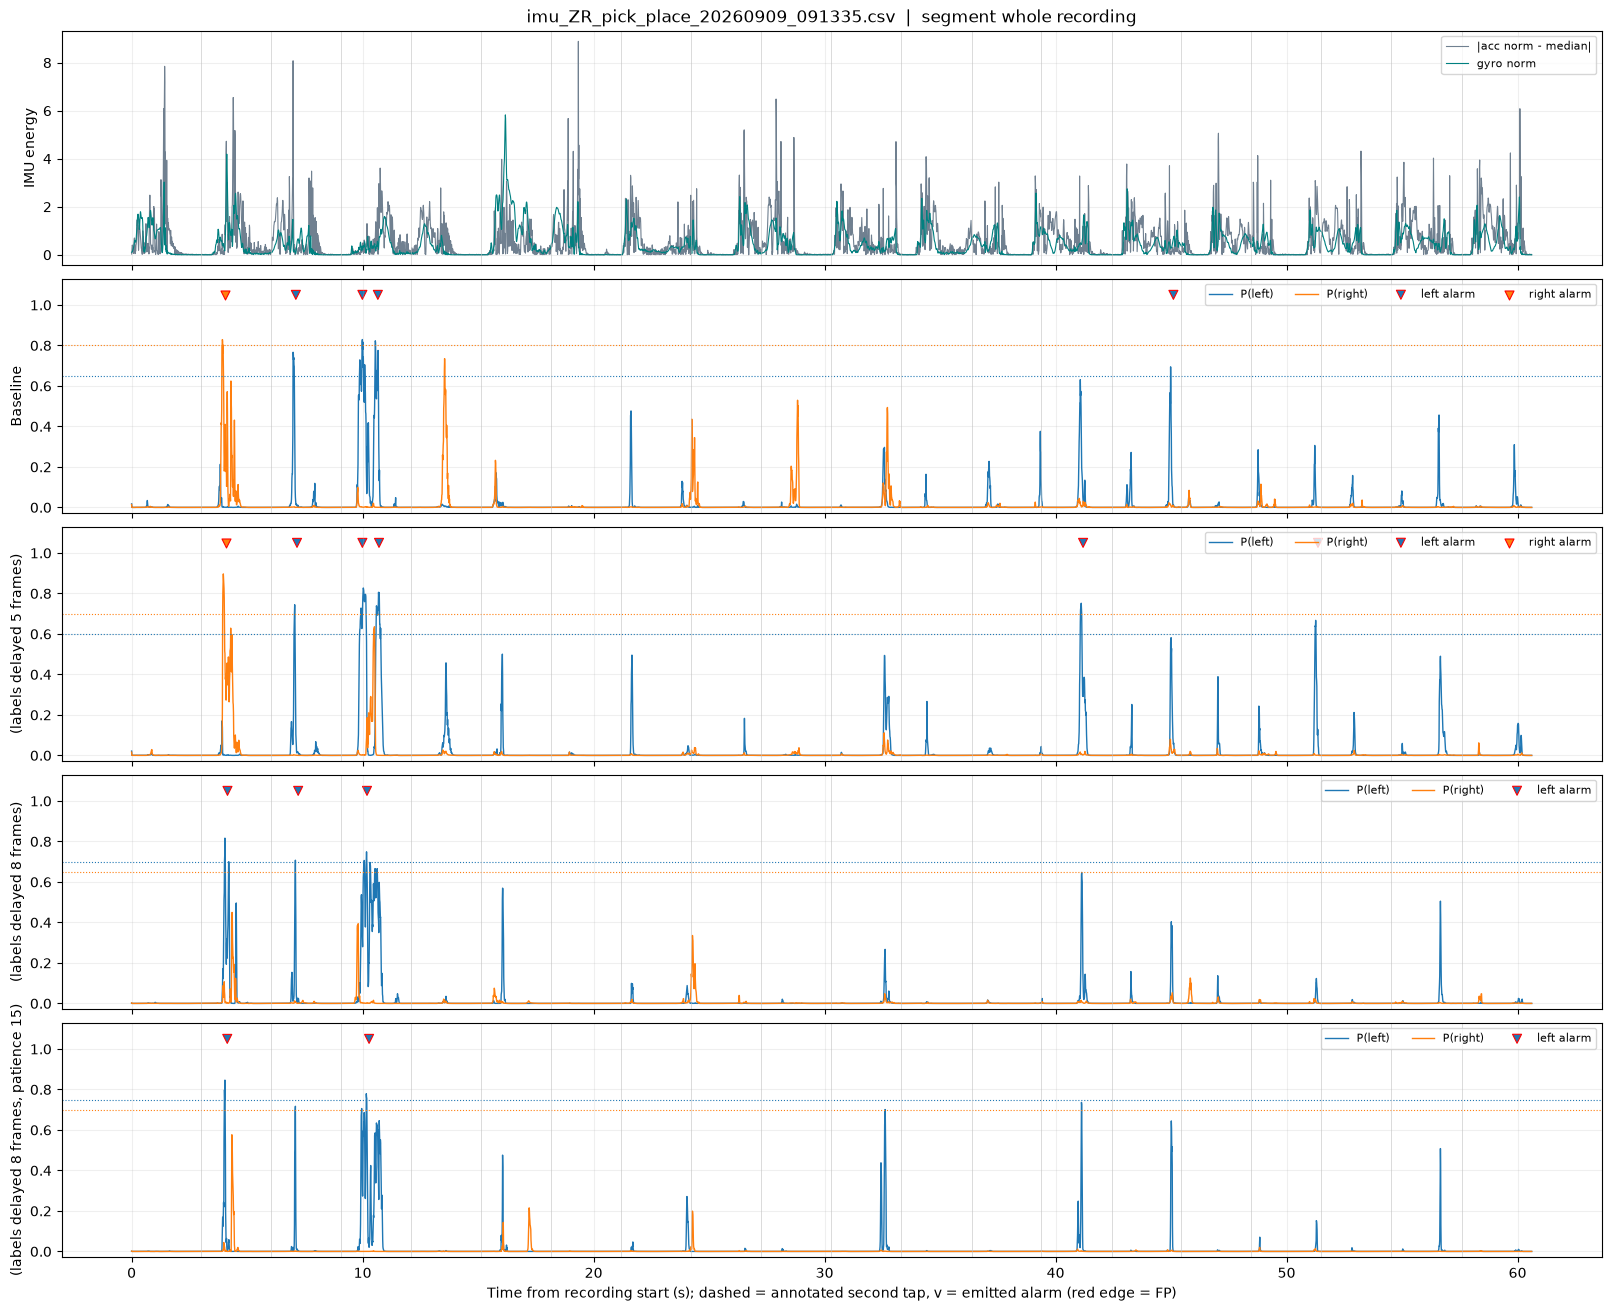

In [45]:
# Replace these values with a file and segment_index from segment_difficulty.
hardest = segment_difficulty.query("recording_type == 'knock_twice'").sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# REVIEW_FILE = hardest['file']
# REVIEW_SEGMENT = int(hardest['segment_index'])  # None = whole recording
REVIEW_FILE = 'imu_ZR_pick_place_20260909_091335.csv'
REVIEW_SEGMENT = None
display(segment_scores.query('file == @REVIEW_FILE and segment_index == @REVIEW_SEGMENT')
        [['model', 'file', 'segment_index', 'window_true', 'window_pred',
          'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
fig, axes = plot_example(example_recordings, example_traces, alarm_details,
                         detail_points, REVIEW_FILE, REVIEW_SEGMENT)
plt.show()